In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [32]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

In [2]:
'''
d4PDF land-sea mask
'''
example = xr.open_dataset('/nesi/project/niwa02986/deansm/data/d4pdf/NZ/HPB/mon/TA/TA_Aday_d4PDF_HPB_m001_1951-2011.nc')
# d4PDF land-sea mask
lsm = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/sftlf_fx_d4PDF_HPB_m000_000000-000000.nc')
lsm = lsm.isel(time=0).drop('time')
lsm = lsm.sel(lon = slice(165,180),lat=slice(-48,-33))
lsm = lsm.interp(lat=example.lat,lon=example.lon)

/nesi/project/niwa00018/queenle/ml_env_v2/lib/python3.8/site-packages/xarray/coding/times.py:152: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:00. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:00). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)


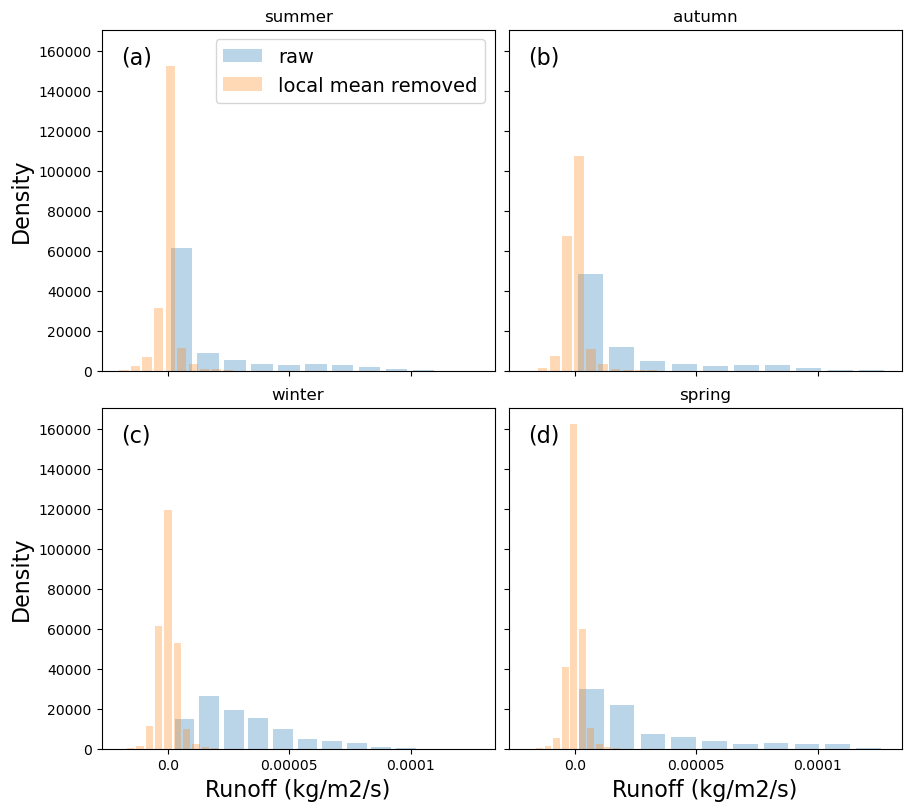

In [53]:
member = 'm067'

dr = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/means'
#ROF_Amon_d4PDF_HPB_FullEnsMean_raw_autumn_1951-2021.nc

fig,axs = plt.subplots(2,2,figsize=(9,8),layout='constrained',sharey=True,sharex=True)
axs= axs.flatten()

labels = ['(a)','(b)','(c)','(d)']
for i,season in enumerate(['summer','autumn','winter','spring']):
    
    raw_season = xr.open_dataarray(f'{dr}/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_{season}_1951-2021.nc')
    raw_mean_removed = raw_season - raw_season.mean('time')
    
    raw_season = raw_season.data.flatten()
    raw_season = raw_season[~np.isnan(raw_season)]
    
    raw_mean_removed = raw_mean_removed.data.flatten()
    raw_mean_removed = raw_mean_removed[~np.isnan(raw_mean_removed)]
    
    axs[i].hist(raw_season,label='raw',alpha=0.3,rwidth=0.8, histtype='barstacked',density=True)#,bins=20)
    axs[i].hist(raw_mean_removed,label='local mean removed',alpha=0.3,rwidth=0.8, histtype='barstacked',density=True)#,bins=20
    
    if i == 0 or i == 2:
        axs[i].set_ylabel('Density',fontdict=font)
        
    if i == 2 or i == 3:
        axs[i].set_xlabel('Runoff (kg/m2/s)',fontdict=font)
        axs[i].set_xticks([0.0,0.00005,0.0001],['0.0','0.00005','0.0001'])
        
    axs[i].set_title(season)
    axs[i].text(0.05,0.9,labels[i],transform=axs[i].transAxes,fontdict=font)
    
axs[0].legend(fontsize=14)

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/ROF_mean_dists.png',dpi=300)


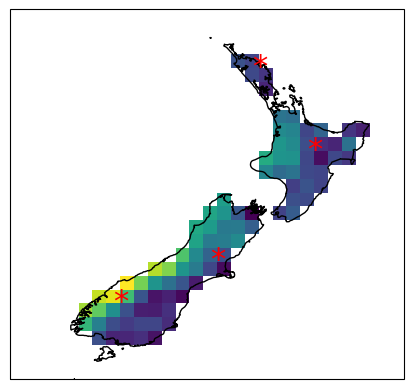

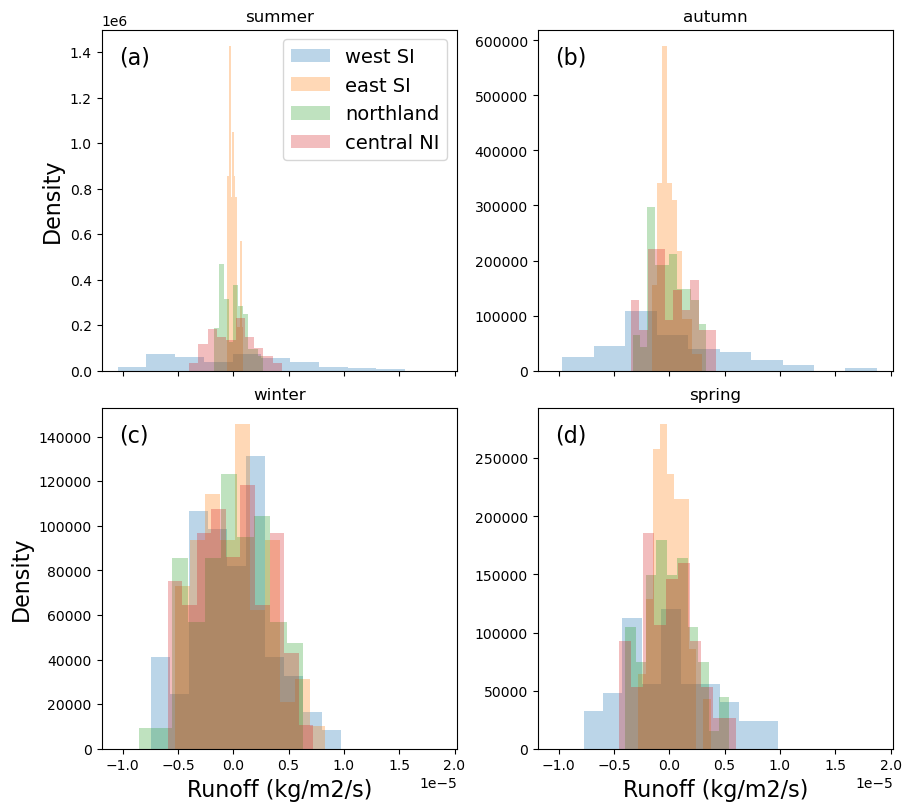

In [58]:
member = 'm067'
locations = {'west SI':[-45,168],'east SI':[-43.5,172],'northland':[-35.5,174],'central NI':[-39,176]}

dr = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/means/'

# PLOT MAP
fig,axs = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

raw_season = xr.open_dataarray(f'{dr}/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_winter_1951-2021.nc')
raw_season.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree(),add_colorbar=False)

for loc in locations:
    ts = raw_season.sel(lat=locations[loc][0],lon=locations[loc][1],method='nearest')
    lat = ts.lat.data
    lon = ts.lon.data
    axs.text(lon,lat,'*',color='red',size=22,transform=ccrs.PlateCarree())
    
axs.coastlines()
axs.set_extent([164,180, -48,-33])
axs.set_title('')
plt.show()


# PLOT DISTS
fig,axs = plt.subplots(2,2,figsize=(9,8),layout='constrained',sharex=True)#,sharey=True)
axs= axs.flatten()

for i,season in enumerate(['summer','autumn','winter','spring']):
    
    raw_season = xr.open_dataarray(f'{dr}/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_{season}_1951-2021.nc')
    
    for loc in locations:
    
        ts = raw_season.sel(lat=locations[loc][0],lon=locations[loc][1],method='nearest')
        ts_norm = ts - ts.mean()
        axs[i].hist(ts_norm.data.flatten(),label=loc,alpha=0.3,density=True)

    axs[i].set_title(season)
    
    if i == 0 or i == 2:
        axs[i].set_ylabel('Density',fontdict=font)
        
    if i == 2 or i == 3:
        axs[i].set_xlabel('Runoff (kg/m2/s)',fontdict=font)
        
    axs[i].text(0.05,0.9,labels[i],transform=axs[i].transAxes,fontdict=font)
        
axs[0].legend(fontsize=14)

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/ROF_select_cells_dists.png',dpi=300)
